# 0. Thiết lập chung

In [49]:
import os
import warnings
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

CUTOFF_DAY = 135
RANDOM_SEED = 42

DATAPATH = "/content/drive/MyDrive/Dataset/"
df_assessments       = pd.read_csv(DATAPATH + 'assessments.csv')
df_studentInfo       = pd.read_csv(DATAPATH + 'studentInfo.csv')
df_studentAssessment = pd.read_csv(DATAPATH + 'studentAssessment.csv')
df_studentRegistration = pd.read_csv(DATAPATH + 'studentRegistration.csv')
df_studentVle        = pd.read_csv(DATAPATH + 'studentVle.csv')
df_courses           = pd.read_csv(DATAPATH + 'courses.csv')
df_vle               = pd.read_csv(DATAPATH + 'vle.csv')

target_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
df_studentInfo['target'] = df_studentInfo['final_result'].map(target_map)
print(df_studentInfo['target'].value_counts())

target
2    12361
0    10156
1     7052
3     3024
Name: count, dtype: int64


# 1. Tiền xử lý & Làm sạch

In [50]:
df_studentRegistration['date_registration'] = pd.to_numeric(df_studentRegistration['date_registration'], errors='coerce')
df_studentRegistration['date_registration'] = df_studentRegistration.groupby(
    ['code_module', 'code_presentation'])['date_registration'].transform(lambda x: x.fillna(x.median()))

if 'date_unregistration' in df_studentRegistration.columns:
    df_studentRegistration = df_studentRegistration.drop(columns=['date_unregistration'])

df_studentInfo['imd_band']  = df_studentInfo['imd_band'].fillna('Unknown')
df_studentInfo['age_band']  = df_studentInfo['age_band'].fillna('Unknown')

if ('week_from' in df_vle.columns) and ('week_to' in df_vle.columns):
    df_vle = df_vle.drop(columns=['week_from', 'week_to'])

df_studentAssessment['score'] = df_studentAssessment['score'].fillna(0)
print('Tiền xử lý xong.')

Tiền xử lý xong.


# 2. Pre-Course Engagement

In [51]:
pre_courses_vle = df_studentVle[df_studentVle['date'] < 0].copy()
pre_courses_engagement = pre_courses_vle.groupby(['id_student']).agg(
    pre_course_clicks      = ('sum_click', 'sum'),
    pre_course_active_days = ('date', 'nunique')
).reset_index()

df_studentInfo = df_studentInfo.drop(columns=['pre_course_clicks', 'pre_course_active_days'], errors='ignore')
df_studentInfo = df_studentInfo.merge(pre_courses_engagement, on='id_student', how='left')
df_studentInfo[['pre_course_clicks', 'pre_course_active_days']] = \
    df_studentInfo[['pre_course_clicks', 'pre_course_active_days']].fillna(0)
df_studentInfo['has_pre_course_activity'] = (df_studentInfo['pre_course_active_days'] > 0).astype(int)
print('Pre-course xong.')

Pre-course xong.


# 3. VLE Temporal Features (weekly + activity breakdown)

In [52]:
df_days_before_cutoff = df_studentVle[
    (df_studentVle['date'] >= 0) & (df_studentVle['date'] <= CUTOFF_DAY)
].copy()

df_vle_before_cutoff = df_days_before_cutoff.groupby(['id_student']).agg(
    last_active_day     = ('date', 'max'),
    std_clicks           = ('sum_click', 'std'),
    active_days         = ('date', 'nunique'),
    total_clicks        = ('sum_click', 'sum'),
    max_daily_clicks    = ('sum_click', 'max'),
    median_daily_clicks = ('sum_click', 'median'),
    first_active_day    = ('date', 'min'),
).reset_index()

df_vle_before_cutoff['days_since_last_active'] = CUTOFF_DAY - df_vle_before_cutoff['last_active_day']
df_vle_before_cutoff['active_span']            = df_vle_before_cutoff['last_active_day'] - df_vle_before_cutoff['first_active_day']
df_vle_before_cutoff['active_rate']            = df_vle_before_cutoff['active_days'] / CUTOFF_DAY
df_vle_before_cutoff['clicks_per_active_day']  = np.where(
    df_vle_before_cutoff['active_days'] > 0,
    df_vle_before_cutoff['total_clicks'] / df_vle_before_cutoff['active_days'], 0)

# Weekly clicks
df_days_before_cutoff['week'] = np.ceil(df_days_before_cutoff['date'] / 7).astype(int)
weekly = df_days_before_cutoff.pivot_table(
    index='id_student', columns='week', values='sum_click', aggfunc='sum', fill_value=0)
weekly.columns = [f'clicks_week_{int(c)}' for c in weekly.columns]

# Activity breakdown
df_detail_studentVle = df_days_before_cutoff.merge(df_vle[['id_site', 'activity_type']], on='id_site', how='left')
avail_types = [t for t in ['oucontent', 'forumng', 'homepage', 'subpage', 'url', 'quiz']
               if t in df_detail_studentVle['activity_type'].values]
df_activity_breakdown = df_detail_studentVle.pivot_table(
    index='id_student', columns='activity_type', values='sum_click', aggfunc='sum', fill_value=0)
df_activity_breakdown = df_activity_breakdown[[c for c in avail_types if c in df_activity_breakdown.columns]]
df_activity_breakdown.columns = [f'clicks_{c}' for c in df_activity_breakdown.columns]

df_studentInfo = df_studentInfo.merge(df_vle_before_cutoff, on='id_student', how='left')
df_studentInfo = df_studentInfo.merge(weekly.reset_index(), on='id_student', how='left')
df_studentInfo = df_studentInfo.merge(df_activity_breakdown.reset_index(), on='id_student', how='left')

vle_fill_cols = ['last_active_day','std_clicks','active_days','total_clicks',
                 'max_daily_clicks','median_daily_clicks','first_active_day',
                 'days_since_last_active','active_span','active_rate','clicks_per_active_day'] \
                + list(weekly.columns) + list(df_activity_breakdown.columns)
for col in vle_fill_cols:
    if col in df_studentInfo.columns:
        df_studentInfo[col] = df_studentInfo[col].fillna(0)

print('VLE temporal xong. Shape:', df_studentInfo.shape)

VLE temporal xong. Shape: (32593, 54)


# Merge thành df_master

In [53]:
df_master = df_studentInfo.copy()

df_master = pd.merge(
    df_master,
    df_studentRegistration[['code_module', 'code_presentation', 'id_student', 'date_registration']],
    on=['code_module', 'code_presentation', 'id_student'], how='left'
)

df_studentAssessment['id_student'] = pd.to_numeric(df_studentAssessment['id_student'], errors='coerce')
df_studentAssessment['score']      = pd.to_numeric(df_studentAssessment['score'], errors='coerce')
df_assessment_agg = df_studentAssessment.groupby('id_student').agg(
    mean_score        = ('score', 'mean'),
    total_assessments = ('id_assessment', 'count')
).reset_index()
df_master = pd.merge(df_master, df_assessment_agg, on='id_student', how='left')
df_master['mean_score']        = df_master['mean_score'].fillna(0)
df_master['total_assessments'] = df_master['total_assessments'].fillna(0)

print('df_master shape:', df_master.shape)

df_master shape: (32593, 57)


# 4A. Assessment Features (weighted score, submission rates)

In [54]:
df_assessments['date'] = pd.to_numeric(df_assessments['date'], errors='coerce')
safe_assessments = df_assessments[
    (df_assessments['date'] <= CUTOFF_DAY) &
    (df_assessments['assessment_type'] != 'Exam')
].copy()

df_student_assessment_safe = pd.merge(
    df_studentAssessment,
    safe_assessments[['id_assessment', 'code_module', 'code_presentation', 'date', 'weight', 'assessment_type']],
    on='id_assessment', how='inner'
)

attempt_keys = ['id_student', 'code_module', 'code_presentation']

weighted_scores = df_student_assessment_safe.groupby(attempt_keys).apply(
    lambda x: (x['score'] * x['weight']).sum() / x['weight'].sum() if x['weight'].sum() > 0 else 0
).reset_index(name='weighted_score_before_cutoff')
weighted_scores['has_weighted_score'] = (weighted_scores['weighted_score_before_cutoff'] > 0).astype(int)

base_attempts = df_master[attempt_keys].drop_duplicates()
total_safe_per_module_type = safe_assessments.groupby(
    ['code_module', 'code_presentation', 'assessment_type']).size().reset_index(name='total_safe')
submitted_per_student = df_student_assessment_safe.groupby(
    attempt_keys + ['assessment_type']).size().reset_index(name='submitted')
expected_submissions = pd.merge(base_attempts, total_safe_per_module_type,
                                on=['code_module', 'code_presentation'], how='inner')
submission_rates = pd.merge(expected_submissions, submitted_per_student,
                            on=attempt_keys + ['assessment_type'], how='left')
submission_rates['submitted']        = submission_rates['submitted'].fillna(0)
submission_rates['submission_rate']  = submission_rates['submitted'] / submission_rates['total_safe']
submission_rates['missing']          = submission_rates['total_safe'] - submission_rates['submitted']

submission_rates_pivot = submission_rates.pivot_table(
    index=attempt_keys, columns='assessment_type', values='submission_rate').reset_index()
submission_rates_pivot = submission_rates_pivot.rename(
    columns={'TMA': 'tma_submission_rate', 'CMA': 'cma_submission_rate'})

n_missing = submission_rates.groupby(attempt_keys)['missing'].sum().reset_index(name='n_missing_submission')

df_student_assessment_safe['days_before_deadline'] = \
    -df_student_assessment_safe['date_submitted'] + df_student_assessment_safe['date']
avg_days = df_student_assessment_safe.groupby(attempt_keys)['days_before_deadline'].mean()\
    .reset_index(name='avg_days_before_deadline')

for feature_df in [weighted_scores, submission_rates_pivot, avg_days, n_missing]:
    df_master = pd.merge(df_master, feature_df, on=attempt_keys, how='left')

df_master['weighted_score_before_cutoff'] = df_master['weighted_score_before_cutoff'].fillna(0)
df_master['has_weighted_score']           = df_master['has_weighted_score'].fillna(0)
df_master['avg_days_before_deadline']     = df_master['avg_days_before_deadline'].fillna(0)
df_master['n_missing_submission']         = df_master['n_missing_submission'].fillna(0)
if 'tma_submission_rate' in df_master.columns:
    df_master['tma_submission_rate'] = df_master['tma_submission_rate'].fillna(-1)
if 'cma_submission_rate' in df_master.columns:
    df_master['cma_submission_rate'] = df_master['cma_submission_rate'].fillna(-1)

print('Assessment features xong. Shape:', df_master.shape)

/tmp/ipykernel_2102/2484063925.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_scores = df_student_assessment_safe.groupby(attempt_keys).apply(


Assessment features xong. Shape: (32593, 63)


# 4B. ★ FEATURES MỚI — Distinction-specific signals


- **Assessment**: `pct_score_above_80/90`, `n_perfect_scores`, `score_cv`, `score_std`, `score_min/max/median`, `weighted_score_sq`
- **VLE temporal split**: `early_clicks`, `mid_clicks`, `late_clicks`  
- **VLE normalized**: `clicks_per_course_day`, `active_rate_vs_course`
- **Composite**: `score_x_engagement`, `score_x_active_rate`, `high_consistent`

In [55]:
# ═══════════════════════════════════════════════════════════════
# 4B-1. Distinction-specific Assessment signals
# ═══════════════════════════════════════════════════════════════
def safe_wavg(x):
    w = x['weight'].sum()
    return (x['score'] * x['weight']).sum() / w if w > 0 else 0

distinction_ass_feat = df_student_assessment_safe.groupby(attempt_keys).apply(lambda x: pd.Series({
    'score_std':           x['score'].std(ddof=0),
    'score_min':           x['score'].min(),
    'score_max':           x['score'].max(),
    'score_median':        x['score'].median(),
    'pct_score_above_80':  (x['score'] >= 80).mean(),
    'pct_score_above_90':  (x['score'] >= 90).mean(),
    'n_perfect_scores':    (x['score'] >= 100).sum(),
    'score_cv':            x['score'].std(ddof=0) / (x['score'].mean() + 1e-6),
    'weighted_score_sq':   safe_wavg(x) ** 2,
})).reset_index()

df_master = pd.merge(df_master, distinction_ass_feat, on=attempt_keys, how='left')
for col in ['score_std','score_min','score_max','score_median',
            'pct_score_above_80','pct_score_above_90','n_perfect_scores',
            'score_cv','weighted_score_sq']:
    if col in df_master.columns:
        df_master[col] = df_master[col].fillna(0)

print('4B-1 Assessment distinction signals xong.')
print('Columns added:', ['score_std','score_min','score_max','score_median',
                         'pct_score_above_80','pct_score_above_90',
                         'n_perfect_scores','score_cv','weighted_score_sq'])

4B-1 Assessment distinction signals xong.
Columns added: ['score_std', 'score_min', 'score_max', 'score_median', 'pct_score_above_80', 'pct_score_above_90', 'n_perfect_scores', 'score_cv', 'weighted_score_sq']


/tmp/ipykernel_2102/1455994644.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  distinction_ass_feat = df_student_assessment_safe.groupby(attempt_keys).apply(lambda x: pd.Series({


In [56]:
# ═══════════════════════════════════════════════════════════════
# 4B-3. VLE normalized by course length
# Cần merge df_courses để lấy module_presentation_length
# ═══════════════════════════════════════════════════════════════
df_master = df_master.merge(
    df_courses[['code_module', 'code_presentation', 'module_presentation_length']],
    on=['code_module', 'code_presentation'], how='left'
)

df_master['clicks_per_course_day']  = df_master['total_clicks'] / (df_master['module_presentation_length'] + 1)
df_master['active_rate_vs_course']  = df_master['active_days'] / (df_master['module_presentation_length'] + 1)

for col in ['clicks_per_course_day', 'active_rate_vs_course']:
    df_master[col] = df_master[col].fillna(0)

print('4B-3 VLE normalized xong.')
print('Columns added: clicks_per_course_day, active_rate_vs_course')

4B-3 VLE normalized xong.
Columns added: clicks_per_course_day, active_rate_vs_course


In [57]:
total = df_master['total_clicks'] + 1  # avoid div0

df_master['ratio_forumng']  = df_master['clicks_forumng']  / total
df_master['ratio_oucontent'] = df_master['clicks_oucontent'] / total
df_master['ratio_homepage'] = df_master['clicks_homepage']  / total
df_master['ratio_quiz']     = df_master['clicks_quiz']      / total
df_master['ratio_subpage']  = df_master['clicks_subpage']   / total

print('Engagement ratio features xong.')
print('Columns added: ratio_forumng, ratio_oucontent, ratio_homepage, ratio_quiz, ratio_subpage')
print('df_master shape:', df_master.shape)


Engagement ratio features xong.
Columns added: ratio_forumng, ratio_oucontent, ratio_homepage, ratio_quiz, ratio_subpage
df_master shape: (32593, 80)


In [58]:
# ═══════════════════════════════════════════════════════════════
# 4B-5. Composite features — kết hợp score × engagement
# Yêu cầu: weighted_score_before_cutoff, total_clicks, active_rate
# đã được tính ở các bước trước
# ═══════════════════════════════════════════════════════════════
df_master['score_x_engagement']  = df_master['weighted_score_before_cutoff'] * df_master['total_clicks']
df_master['score_x_active_rate'] = df_master['weighted_score_before_cutoff'] * df_master['active_rate']

# high_consistent: sinh viên điểm cao VÀ ổn định (Distinction pattern)
df_master['high_consistent'] = (
    (df_master['weighted_score_before_cutoff'] >= 75) &
    (df_master['score_cv'] < 0.2)
).astype(int)

# Thêm: interaction giữa forum và score (Distinction hay dùng forum)
if 'clicks_forumng' in df_master.columns:
    df_master['forum_x_score'] = df_master['clicks_forumng'] * df_master['weighted_score_before_cutoff']

print('4B-5 Composite features xong.')
print('Columns added: score_x_engagement, score_x_active_rate, high_consistent, forum_x_score')

4B-5 Composite features xong.
Columns added: score_x_engagement, score_x_active_rate, high_consistent, forum_x_score


# 4C. ★ FEATURES MỚI — Fail vs Withdrawn signals

Phân biệt **Withdrawn** (biến mất đột ngột) vs **Fail** (cố gắng đến cuối nhưng không đủ điểm):
- **Biến mất**: `days_since_last_active`, `active_days_last_4weeks`, `consecutive_zero_weeks`, `click_dropout_week`
- **Đăng ký**: `unreg_before_cutoff`, `days_enrolled_at_cutoff`, `registered_early`
- **Nộp bài**: `n_submitted`, `submission_trend`, `score_trend`, `n_late_submissions`

In [59]:
# ═══════════════════════════════════════════════════════════════
# 4C-1. "Biến mất" signals — đặc trưng Withdrawn
# Withdrawn ngừng hẳn trước cutoff, Fail vẫn còn lác đác cuối kỳ
# ═══════════════════════════════════════════════════════════════

vle_pos = df_studentVle[(df_studentVle['date'] >= 0) & (df_studentVle['date'] <= CUTOFF_DAY)].copy()

# days_since_last_active đã có từ Session 3, đảm bảo tính đúng
# (CUTOFF_DAY - last_active_day): Withdrawn thường cao, Fail thấp hơn
if 'days_since_last_active' not in df_master.columns:
    last_day = vle_pos.groupby('id_student')['date'].max().reset_index(name='last_active_day_tmp')
    df_master = df_master.merge(last_day, on='id_student', how='left')
    df_master['days_since_last_active'] = CUTOFF_DAY - df_master['last_active_day_tmp'].fillna(0)
    df_master = df_master.drop(columns=['last_active_day_tmp'], errors='ignore')

# active_days_last_4weeks: số ngày active trong 28 ngày cuối trước cutoff
# Withdrawn thường = 0, Fail vẫn còn vài ngày
last4w = vle_pos[vle_pos['date'] >= (CUTOFF_DAY - 28)].copy()
last4w_agg = last4w.groupby('id_student')['date'].nunique().reset_index(name='active_days_last_4weeks')
df_master = df_master.drop(columns=['active_days_last_4weeks'], errors='ignore')
df_master = df_master.merge(last4w_agg, on='id_student', how='left')
df_master['active_days_last_4weeks'] = df_master['active_days_last_4weeks'].fillna(0)

# consecutive_zero_weeks: số tuần liên tiếp không có click (tính ngược từ cutoff)
vle_pos['week'] = (vle_pos['date'] // 7).astype(int)
active_weeks = vle_pos.groupby('id_student')['week'].apply(set).reset_index(name='active_week_set')
total_weeks = CUTOFF_DAY // 7

def count_trailing_zero_weeks(active_set):
    count = 0
    for w in range(total_weeks, -1, -1):
        if w not in active_set:
            count += 1
        else:
            break
    return count

active_weeks['consecutive_zero_weeks'] = active_weeks['active_week_set'].apply(count_trailing_zero_weeks)
df_master = df_master.drop(columns=['consecutive_zero_weeks'], errors='ignore')
df_master = df_master.merge(active_weeks[['id_student', 'consecutive_zero_weeks']], on='id_student', how='left')
df_master['consecutive_zero_weeks'] = df_master['consecutive_zero_weeks'].fillna(total_weeks)

# click_dropout_week: tuần cuối cùng có click (Withdrawn thường thấp, Fail cao hơn)
dropout_week = vle_pos.groupby('id_student')['week'].max().reset_index(name='click_dropout_week')
df_master = df_master.drop(columns=['click_dropout_week'], errors='ignore')
df_master = df_master.merge(dropout_week, on='id_student', how='left')
df_master['click_dropout_week'] = df_master['click_dropout_week'].fillna(0)

print('4C-1 Biến mất signals xong.')
print('Columns added: days_since_last_active, active_days_last_4weeks, consecutive_zero_weeks, click_dropout_week')


4C-1 Biến mất signals xong.
Columns added: days_since_last_active, active_days_last_4weeks, consecutive_zero_weeks, click_dropout_week


In [60]:
# ═══════════════════════════════════════════════════════════════
# 4C-2. Đăng ký signals — tín hiệu sớm nhất
# unreg_before_cutoff gần như chắc chắn = Withdrawn
# ═══════════════════════════════════════════════════════════════

# Đọc lại registration gốc (có date_unregistration trước khi bị drop)
df_reg_raw = pd.read_csv(DATAPATH + 'studentRegistration.csv')
df_reg_raw['date_registration']   = pd.to_numeric(df_reg_raw['date_registration'],   errors='coerce')
df_reg_raw['date_unregistration'] = pd.to_numeric(df_reg_raw['date_unregistration'], errors='coerce')

attempt_keys = ['id_student', 'code_module', 'code_presentation']

# Điền median cho date_registration bị null
df_reg_raw['date_registration'] = df_reg_raw.groupby(
    ['code_module', 'code_presentation'])['date_registration'].transform(lambda x: x.fillna(x.median()))

reg_signals = df_reg_raw[attempt_keys + ['date_registration', 'date_unregistration']].copy()

# days_enrolled_at_cutoff: số ngày đã học tính đến cutoff (SAFE)
reg_signals['days_enrolled_at_cutoff'] = CUTOFF_DAY - reg_signals['date_registration']

# registered_early: đăng ký trước ngày khai giảng (SAFE)
reg_signals['registered_early'] = (reg_signals['date_registration'] < -10).astype(int)

merge_reg_cols = ['days_enrolled_at_cutoff', 'registered_early']  # ← đổi tên biến cho khỏi đánh lừa
df_master = df_master.drop(columns=merge_reg_cols, errors='ignore')
df_master = df_master.merge(
    reg_signals[attempt_keys + merge_reg_cols],
    on=attempt_keys, how='left'
)
for col in merge_reg_cols:
    df_master[col] = df_master[col].fillna(0)

In [61]:
# ═══════════════════════════════════════════════════════════════
# 4C-3. Nộp bài signals — Fail cố nộp, Withdrawn bỏ giữa chừng
# ═══════════════════════════════════════════════════════════════

attempt_keys = ['id_student', 'code_module', 'code_presentation']

# n_submitted: tổng số bài đã nộp trước cutoff (Withdrawn thấp hoặc 0)
n_submitted = df_student_assessment_safe.groupby(attempt_keys).size().reset_index(name='n_submitted')
df_master = df_master.drop(columns=['n_submitted'], errors='ignore')
df_master = df_master.merge(n_submitted, on=attempt_keys, how='left')
df_master['n_submitted'] = df_master['n_submitted'].fillna(0)

# submission_trend: tỷ lệ nộp bài nửa đầu vs nửa cuối kỳ
# Withdrawn thường nộp đầu kỳ rồi dừng; Fail nộp đều hoặc giảm nhẹ
mid_cutoff = CUTOFF_DAY // 2
early_sub = df_student_assessment_safe[df_student_assessment_safe['date'] <= mid_cutoff]    .groupby(attempt_keys).size().reset_index(name='n_submitted_early')
late_sub  = df_student_assessment_safe[df_student_assessment_safe['date'] > mid_cutoff]    .groupby(attempt_keys).size().reset_index(name='n_submitted_late')

df_master = df_master.drop(columns=['n_submitted_early','n_submitted_late','submission_trend'], errors='ignore')
df_master = df_master.merge(early_sub, on=attempt_keys, how='left')
df_master = df_master.merge(late_sub,  on=attempt_keys, how='left')
df_master['n_submitted_early'] = df_master['n_submitted_early'].fillna(0)
df_master['n_submitted_late']  = df_master['n_submitted_late'].fillna(0)
# submission_trend > 1: tăng về cuối (Distinction/Pass); < 1: giảm (Fail); ~0: Withdrawn
df_master['submission_trend'] = (df_master['n_submitted_late'] + 1) / (df_master['n_submitted_early'] + 1)

# score_trend: điểm bài đầu kỳ vs cuối kỳ
# Fail thường điểm thấp đều; Withdrawn không có bài cuối kỳ
early_score = df_student_assessment_safe[df_student_assessment_safe['date'] <= mid_cutoff]    .groupby(attempt_keys)['score'].mean().reset_index(name='score_early')
late_score  = df_student_assessment_safe[df_student_assessment_safe['date'] > mid_cutoff]    .groupby(attempt_keys)['score'].mean().reset_index(name='score_late')

df_master = df_master.drop(columns=['score_early','score_late','score_trend'], errors='ignore')
df_master = df_master.merge(early_score, on=attempt_keys, how='left')
df_master = df_master.merge(late_score,  on=attempt_keys, how='left')
df_master['score_early'] = df_master['score_early'].fillna(0)
df_master['score_late']  = df_master['score_late'].fillna(0)
df_master['score_trend'] = df_master['score_late'] - df_master['score_early']

# n_late_submissions: số bài nộp trễ hạn (Fail hay nộp trễ, Withdrawn không nộp luôn)
if 'date_submitted' in df_student_assessment_safe.columns:
    df_student_assessment_safe['is_late'] = (
        df_student_assessment_safe['date_submitted'] > df_student_assessment_safe['date']
    ).astype(int)
    n_late = df_student_assessment_safe.groupby(attempt_keys)['is_late'].sum().reset_index(name='n_late_submissions')
    df_master = df_master.drop(columns=['n_late_submissions'], errors='ignore')
    df_master = df_master.merge(n_late, on=attempt_keys, how='left')
    df_master['n_late_submissions'] = df_master['n_late_submissions'].fillna(0)
else:
    df_master['n_late_submissions'] = 0

print('4C-3 Nộp bài signals xong.')
print('Columns added: n_submitted, n_submitted_early, n_submitted_late, submission_trend, score_early, score_late, score_trend, n_late_submissions')


4C-3 Nộp bài signals xong.
Columns added: n_submitted, n_submitted_early, n_submitted_late, submission_trend, score_early, score_late, score_trend, n_late_submissions


In [62]:
from scipy.stats import linregress

def click_slope_r2(row):
    """Trả slope và R² (linearity của trend)."""
    weeks = np.arange(len(row))
    if row.sum() == 0 or row.std() == 0:
        return pd.Series({'click_slope': 0.0, 'click_slope_r2': 0.0})
    result = linregress(weeks, row.values)
    return pd.Series({
        'click_slope': result.slope,
        'click_slope_r2': result.rvalue ** 2,  # 0..1
    })

slope_features = weekly.apply(click_slope_r2, axis=1).reset_index()
df_master = df_master.drop(columns=['click_slope', 'click_slope_r2'], errors='ignore')
df_master = df_master.merge(slope_features, on='id_student', how='left')
df_master[['click_slope', 'click_slope_r2']] = df_master[['click_slope', 'click_slope_r2']].fillna(0)

In [63]:
df_w = df_reg_raw[df_reg_raw['date_unregistration'].notna()].copy()
df_w['phase'] = pd.cut(
    df_w['date_unregistration'],
    bins=[-np.inf, 14, 90, 180, np.inf],
    labels=['A_free_refund (<14)', 'B_25%_loss (14-90)', 'C_50%_loss (90-180)', 'D_100%_loss (>180)']
)
print(df_w['phase'].value_counts(normalize=True).sort_index() * 100)
print('\nTotal withdrawals:', len(df_w))

phase
A_free_refund (<14)    44.420175
B_25%_loss (14-90)     25.387212
C_50%_loss (90-180)    22.706513
D_100%_loss (>180)      7.486100
Name: proportion, dtype: float64

Total withdrawals: 10072


In [64]:
df_w['phase'] = pd.cut(df_w['date_unregistration'], bins=[-np.inf,14,90,180,np.inf],
                       labels=['A','B','C','D'])
merged = df_master.merge(df_w[['id_student','code_module','code_presentation','phase']],
                         on=['id_student','code_module','code_presentation'])
print(merged.groupby('phase')[['n_submitted','days_since_last_active','total_clicks']].median())

       n_submitted  days_since_last_active  total_clicks
phase                                                   
A              0.0                     0.0           0.0
B              1.0                    81.0         235.0
C              3.0                    16.0         482.0
D              3.0                     4.0         562.5


/tmp/ipykernel_2102/537258387.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(merged.groupby('phase')[['n_submitted','days_since_last_active','total_clicks']].median())


# 5. Context & Demographic

In [65]:
df_master['module_semester'] = df_master['code_module'] + '_' + df_master['code_presentation']
df_master['semester']        = df_master['code_presentation'].str[-1]
# df_master = df_master.drop(columns=['gender'], errors='ignore')
print('Context & demographic xong.')

Context & demographic xong.


# 6. Train/Test Split + Encoding + Scaling

In [66]:
student_info = df_studentInfo[['id_student', 'final_result', 'code_module']].drop_duplicates('id_student').copy()
student_info['stratify_col'] = student_info['final_result'] + '_' + student_info['code_module']

train_students, test_students = train_test_split(
    student_info, test_size=0.2,
    stratify=student_info['stratify_col'],
    random_state=RANDOM_SEED
)
train_ids = set(train_students['id_student'])
test_ids  = set(test_students['id_student'])

df_train = df_master[df_master['id_student'].isin(train_ids)].copy()
df_test  = df_master[df_master['id_student'].isin(test_ids)].copy()

# Encoding (fit trên train)
education_order = ['No Formal quals','Lower Than A Level','A Level or Equivalent',
                   'HE Qualification','Post Graduate Qualification']
age_order  = ['0-35','35-55','55<=']
imd_order  = ['0-10%','10-20%','20-30%','30-40%','40-50%',
               '50-60%','60-70%','70-80%','80-90%','90-100%','Unknown']

for df in [df_train, df_test]:
    df['highest_education_encoded'] = df['highest_education'].map(
        {v: i for i, v in enumerate(education_order)}).fillna(2)
    df['age_band_encoded']  = df['age_band'].map({v: i for i, v in enumerate(age_order)}).fillna(0)
    df['imd_band_encoded']  = df['imd_band'].map({v: i for i, v in enumerate(imd_order)}).fillna(5)
    df['semester_enc']      = (df['semester'] == 'B').astype(int)

    # Encode gender
    df['gender_encoded'] = df['gender'].map({'M': 0, 'F': 1}).fillna(-1) # Use -1 for unknown if any
    # Encode disability
    df['disability_encoded'] = df['disability'].map({'N': 0, 'Y': 1}).fillna(-1) # Use -1 for unknown if any


le_module = LabelEncoder()
df_train['module_semester_encoded'] = le_module.fit_transform(df_train['module_semester'])
df_test['module_semester_encoded']  = le_module.transform(df_test['module_semester'])

# Region dummies
region_dummies_train = pd.get_dummies(df_train['region'], prefix='region', drop_first=True).astype(int)
region_dummies_test  = pd.get_dummies(df_test['region'],  prefix='region', drop_first=True).astype(int)
region_dummies_test  = region_dummies_test.reindex(columns=region_dummies_train.columns, fill_value=0)
df_train = pd.concat([df_train, region_dummies_train], axis=1)
df_test  = pd.concat([df_test,  region_dummies_test],  axis=1)

# Feature columns (numeric only, exclude metadata)
exclude_cols = ['id_student','code_module','code_presentation','final_result',
                'module_semester','highest_education','age_band','imd_band',
                'region','gender','disability','semester','target', 'total_clicks'] # Added 'gender', removed 'disability' to include encoded
feature_cols = [c for c in df_train.columns
                if c not in exclude_cols
                and df_train[c].dtype in ['int64','float64','int32','float32','uint8','bool']]

# Scaling
scaler = StandardScaler()
df_train_scaled = df_train.copy()
df_test_scaled  = df_test.copy()
scaler.fit(df_train[feature_cols])
df_train_scaled[feature_cols] = scaler.transform(df_train[feature_cols])
df_test_scaled[feature_cols]  = scaler.transform(df_test[feature_cols])

print(f'Train: {df_train.shape} | Test: {df_test.shape}')
print(f'Total features: {len(feature_cols)}')
print('Class dist (train):', df_train['target'].value_counts().sort_index().to_dict())


Train: (26063, 120) | Test: (6530, 120)
Total features: 106
Class dist (train): {0: 8113, 1: 5642, 2: 9896, 3: 2412}


Categorical: giữ 17, bỏ 0 → []
Numerical:   giữ 43, bỏ 0 → []
Total features còn lại: 60


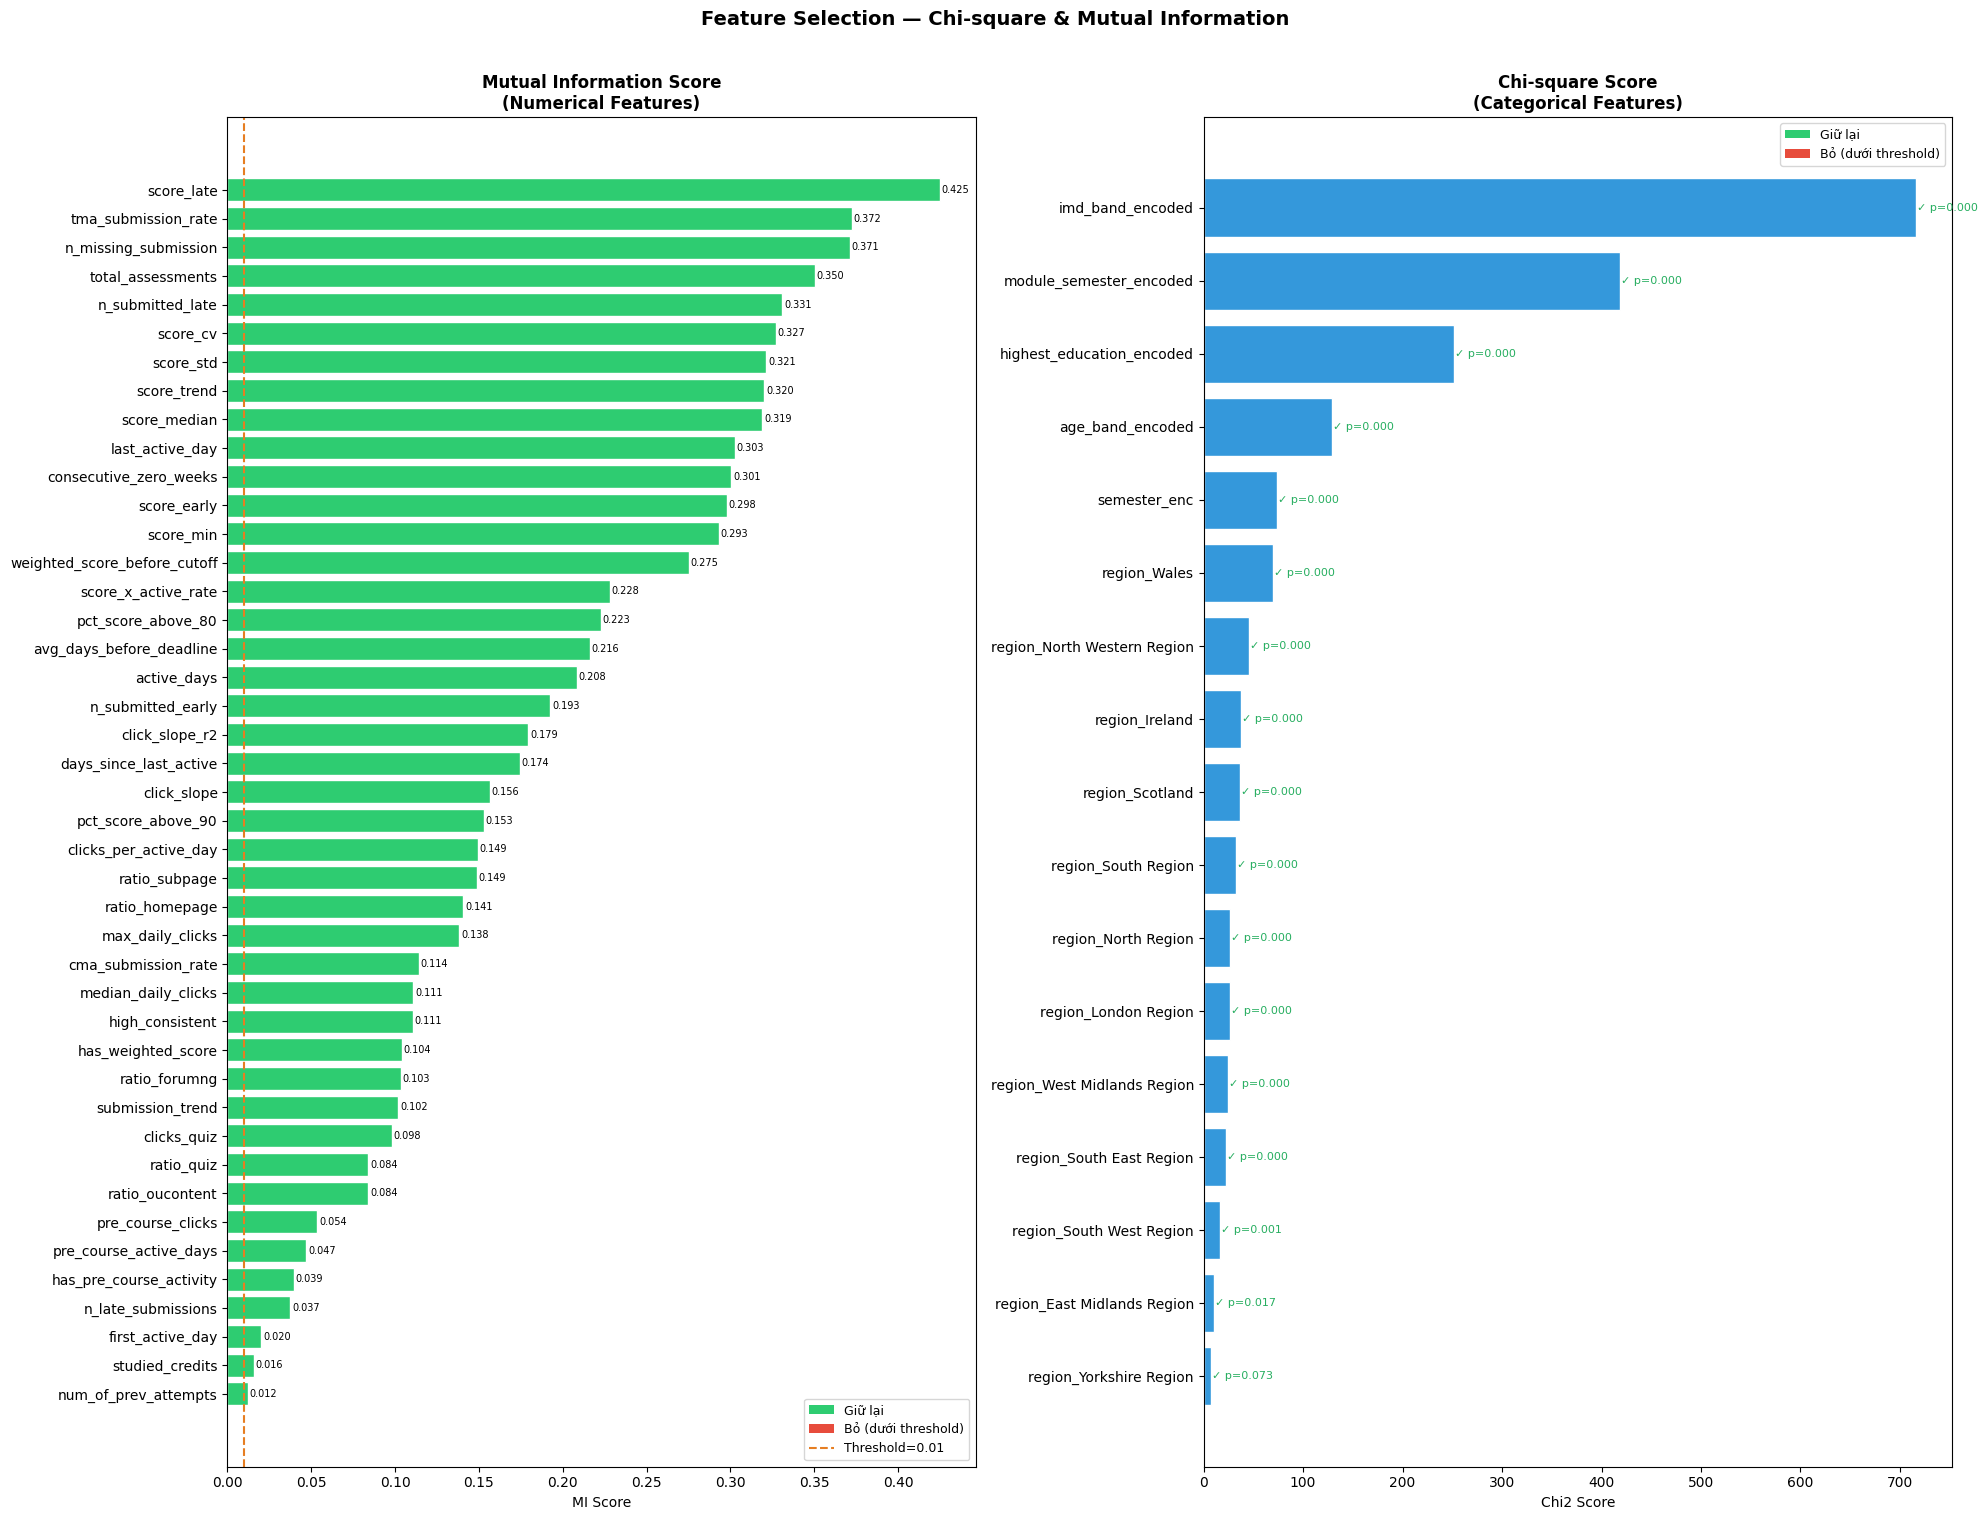


Final feature list (60 features):
  active_days
  age_band_encoded
  avg_days_before_deadline
  click_slope
  click_slope_r2
  clicks_per_active_day
  clicks_quiz
  cma_submission_rate
  consecutive_zero_weeks
  days_since_last_active
  first_active_day
  has_pre_course_activity
  has_weighted_score
  high_consistent
  highest_education_encoded
  imd_band_encoded
  last_active_day
  max_daily_clicks
  median_daily_clicks
  module_semester_encoded
  n_late_submissions
  n_missing_submission
  n_submitted_early
  n_submitted_late
  num_of_prev_attempts
  pct_score_above_80
  pct_score_above_90
  pre_course_active_days
  pre_course_clicks
  ratio_forumng
  ratio_homepage
  ratio_oucontent
  ratio_quiz
  ratio_subpage
  region_East Midlands Region
  region_Ireland
  region_London Region
  region_North Region
  region_North Western Region
  region_Scotland
  region_South East Region
  region_South Region
  region_South West Region
  region_Wales
  region_West Midlands Region
  region_Yorks

In [75]:
from sklearn.feature_selection import chi2, mutual_info_classif, f_classif
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Phân loại features ─────────────────────────────────────────────────
categorical_features = [
    'highest_education_encoded', 'age_band_encoded', 'imd_band_encoded',
    'semester_enc', 'module_semester_encoded'
]
categorical_features.extend([col for col in feature_cols if col.startswith('region_')])
categorical_features = [f for f in categorical_features if f in df_train.columns]

numerical_features = [f for f in feature_cols
                      if f not in categorical_features and f in df_train.columns]

X_cat = df_train[categorical_features]
X_num = df_train[numerical_features]
y     = df_train['target']

# ── 2. Chi-square (categorical) ───────────────────────────────────────────
chi2_scores, chi2_pvals = chi2(X_cat, y)
df_chi2 = pd.DataFrame({
    'feature': categorical_features,
    'score':   chi2_scores,
    'p_value': chi2_pvals,
    'method':  'chi2'
}).sort_values('score', ascending=False)

# ── 3. Mutual Information + F-score (numerical) ───────────────────────────
mi_scores            = mutual_info_classif(X_num, y, random_state=42)
f_scores, f_pvals    = f_classif(X_num, y)

df_num = pd.DataFrame({
    'feature': numerical_features,
    'mi_score': mi_scores,
    'f_score':  f_scores,
    'p_value':  f_pvals,
    'method':   'mi+f'
}).sort_values('mi_score', ascending=False)

# ── 4. Filter theo threshold ──────────────────────────────────────────────
keep_cat = df_chi2[df_chi2['p_value'] <= 0.1]['feature'].tolist() # Changed p-value threshold to 0.1
drop_cat = df_chi2[df_chi2['p_value'] >  0.1]['feature'].tolist() # Changed p-value threshold to 0.1

keep_num = df_num[df_num['mi_score'] >= 0.01]['feature'].tolist()
drop_num = df_num[df_num['mi_score'] <  0.01]['feature'].tolist()

print(f"Categorical: giữ {len(keep_cat)}, bỏ {len(drop_cat)} → {drop_cat}")
print(f"Numerical:   giữ {len(keep_num)}, bỏ {len(drop_num)} → {drop_num}")
print(f"Total features còn lại: {len(keep_cat) + len(keep_num)}")

# ── 5. Visualize ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 15)) # Adjusted figure size

# Plot A: Numerical — MI score (all features)
ax = axes[0]
# Changed to plot all numerical features
top_num = df_num.sort_values('mi_score')
colors_num = ['#e74c3c' if f in drop_num else '#2ecc71' for f in top_num['feature']]
bars = ax.barh(top_num['feature'], top_num['mi_score'], color=colors_num, edgecolor='white')
ax.axvline(0.01, color='#e67e22', linestyle='--', linewidth=1.5, label='Threshold = 0.01')
ax.set_title('Mutual Information Score\n(Numerical Features)', fontsize=12, fontweight='bold')
ax.set_xlabel('MI Score')
ax.legend()

# Annotate bars
for bar, val in zip(bars, top_num['mi_score']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7)

# Plot B: Categorical — Chi2 score (all features)
ax = axes[1]
df_chi2_sorted = df_chi2.sort_values('score')
colors_cat = ['#e74c3c' if f in drop_cat else '#3498db' for f in df_chi2_sorted['feature']]
bars2 = ax.barh(df_chi2_sorted['feature'], df_chi2_sorted['score'],
                color=colors_cat, edgecolor='white')
ax.set_title('Chi-square Score\n(Categorical Features)', fontsize=12, fontweight='bold')
ax.set_xlabel('Chi2 Score')

# Annotate p-value
for bar, (_, row) in zip(bars2, df_chi2_sorted.iterrows()):
    marker = '✓' if row['p_value'] <= 0.1 else '✗' # Changed p-value threshold to 0.1
    color  = '#27ae60' if row['p_value'] <= 0.1 else '#e74c3c' # Changed p-value threshold to 0.1
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{marker} p={row["p_value"]:.3f}', va='center', fontsize=8, color=color)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Giữ lại'),
    Patch(facecolor='#e74c3c', label='Bỏ (dưới threshold)'),
]
axes[0].legend(handles=legend_elements + [plt.Line2D([0],[0], color='#e67e22',
               linestyle='--', label='Threshold=0.01')], fontsize=9)
axes[1].legend(handles=legend_elements, fontsize=9)

plt.suptitle('Feature Selection — Chi-square & Mutual Information',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── 6. Final feature list ─────────────────────────────────────────────────
final_features = keep_cat + keep_num
print(f"\nFinal feature list ({len(final_features)} features):")
for f in sorted(final_features):
    print(f"  {f}")

# 7. Xuất dữ liệu

In [67]:
print(len(feature_cols))

106


In [68]:
redundant_features = [
    # Features identified for dropping by Chi-square/Mutual Information analysis
    'date_registration',
    'disability_encoded',
    'gender_encoded',
    # Round 1 (original manual list for discussion, can be removed or kept as needed)
    'registered_early',
    'click_dropout_week',
    'active_rate',
    'active_rate_vs_course',
    'days_enrolled_at_cutoff',
    'weighted_score_sq',
    'forum_x_score',
    'score_x_engagement',
    'module_presentation_length',
    # Round 2 — Cụm 1: clicks_week prune
    'clicks_week_0',
    'clicks_week_1',
    'clicks_week_2',
    'clicks_week_3',
    'clicks_week_4',
    'clicks_week_5',
    'clicks_week_6',
    'clicks_week_7',
    'clicks_week_8',
    'clicks_week_9',
    'clicks_week_10',
    'clicks_week_11',
    'clicks_week_12',
    'clicks_week_13',
    'clicks_week_14',
    'clicks_week_15',
    'clicks_week_16',
    'clicks_week_17',
    'clicks_week_18',
    'clicks_week_19',
    'clicks_week_20',
    # Round 2 — Cụm 2: Score redundancy
    'mean_score',
    'score_max',
    'n_perfect_scores',
    # Round 2 — Cụm 3: Submission redundancy
    'n_submitted',
    # Round 2 — Additional temporal / VLE redundancy
    'active_span',
    'std_clicks',
    'clicks_per_course_day',
    # Round 2 — Absolute click features (replaced by ratio_* equivalents)
    'clicks_forumng',
    'clicks_homepage',
    'clicks_oucontent',
    'clicks_subpage',
    'clicks_url',
    'active_days_last_4weeks'
]

# Remove redundant features from feature_cols
feature_cols = [f for f in feature_cols if f not in redundant_features]

# Remove redundant features from scaled dataframes
df_train_scaled = df_train_scaled.drop(columns=redundant_features, errors='ignore')
df_test_scaled  = df_test_scaled.drop(columns=redundant_features, errors='ignore')

print(f'Đã loại bỏ {len(redundant_features)} features dư thừa.')
print(f'Số lượng features còn lại: {len(feature_cols)}')
print(f'Train scaled shape: {df_train_scaled.shape}')
print(f'Test scaled shape: {df_test_scaled.shape}')

Đã loại bỏ 46 features dư thừa.
Số lượng features còn lại: 60
Train scaled shape: (26063, 74)
Test scaled shape: (6530, 74)


In [69]:
print(f'Total: {len(feature_cols)} features')
for f in sorted(feature_cols):
    print(' ', f)

Total: 60 features
  active_days
  age_band_encoded
  avg_days_before_deadline
  click_slope
  click_slope_r2
  clicks_per_active_day
  clicks_quiz
  cma_submission_rate
  consecutive_zero_weeks
  days_since_last_active
  first_active_day
  has_pre_course_activity
  has_weighted_score
  high_consistent
  highest_education_encoded
  imd_band_encoded
  last_active_day
  max_daily_clicks
  median_daily_clicks
  module_semester_encoded
  n_late_submissions
  n_missing_submission
  n_submitted_early
  n_submitted_late
  num_of_prev_attempts
  pct_score_above_80
  pct_score_above_90
  pre_course_active_days
  pre_course_clicks
  ratio_forumng
  ratio_homepage
  ratio_oucontent
  ratio_quiz
  ratio_subpage
  region_East Midlands Region
  region_Ireland
  region_London Region
  region_North Region
  region_North Western Region
  region_Scotland
  region_South East Region
  region_South Region
  region_South West Region
  region_Wales
  region_West Midlands Region
  region_Yorkshire Region
  sc

(26063, 60)


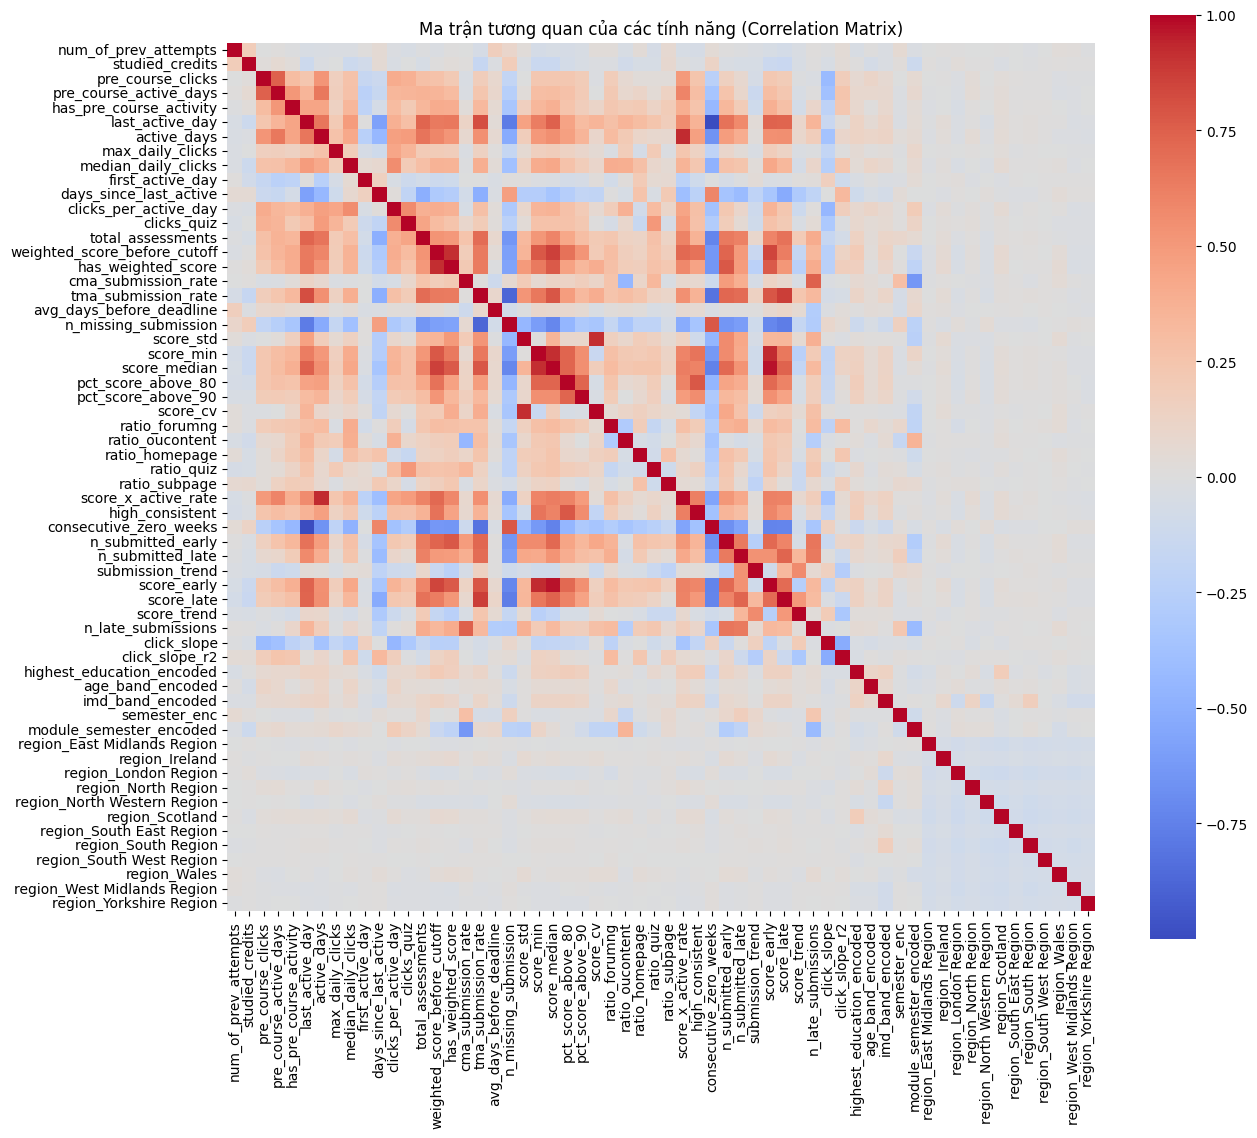

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

X_train = df_train_scaled[feature_cols]
print(X_train.shape)
y_train = df_train_scaled['target']
# Tính ma trận tương quan trên tập train đã impute
X_train = df_train_scaled[feature_cols]
corr_matrix = pd.DataFrame(X_train, columns=feature_cols).corr()

# Vẽ heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', square=True)
plt.title('Ma trận tương quan của các tính năng (Correlation Matrix)')
plt.show()

In [71]:
import json
output_path = DATAPATH

df_master.to_csv(output_path + 'df_master.csv', index=False)
df_train.to_csv(output_path + 'df_train.csv', index=False)
df_test.to_csv(output_path + 'df_test.csv', index=False)
df_train_scaled.to_csv(output_path + 'df_train_scaled.csv', index=False)
df_test_scaled.to_csv(output_path + 'df_test_scaled.csv', index=False)

with open(output_path + 'feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print(f'Xuất xong {len(feature_cols)} features vào {output_path}')
print('Files: df_master.csv, df_train.csv, df_test.csv, df_train_scaled.csv, df_test_scaled.csv, feature_cols.json')

Xuất xong 60 features vào /content/drive/MyDrive/Dataset/
Files: df_master.csv, df_train.csv, df_test.csv, df_train_scaled.csv, df_test_scaled.csv, feature_cols.json


In [72]:
len(feature_cols)

60

In [73]:
display(df_train[feature_cols].head(5))

,num_of_prev_attempts,studied_credits,pre_course_clicks,pre_course_active_days,has_pre_course_activity,last_active_day,active_days,max_daily_clicks,median_daily_clicks,first_active_day,...,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,0,240,98.0,1.0,1,129.0,28.0,76.0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0,60,215.0,7.0,1,134.0,43.0,19.0,2.0,0.0,...,0,0,0,1,0,0,0,0,0,0
2,0,60,102.0,6.0,1,12.0,6.0,23.0,3.0,4.0,...,0,0,1,0,0,0,0,0,0,0
3,0,60,169.0,5.0,1,135.0,71.0,15.0,2.0,1.0,...,0,0,0,0,1,0,0,0,0,0
4,0,60,295.0,8.0,1,134.0,39.0,19.0,2.0,1.0,...,0,0,0,0,0,0,0,0,1,0


In [74]:
display(df_train_scaled[feature_cols].head(5))

,num_of_prev_attempts,studied_credits,pre_course_clicks,pre_course_active_days,has_pre_course_activity,last_active_day,active_days,max_daily_clicks,median_daily_clicks,first_active_day,...,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,-0.341452,3.911999,0.112167,-0.675655,0.558575,0.589659,-0.308452,0.331829,0.872159,-0.422024,...,-0.328889,-0.242274,-0.311925,-0.341495,-0.263240,-0.325872,-0.283665,-0.260983,-0.295035,-0.257781
1,-0.341452,-0.483066,0.890893,0.741959,0.558575,0.689937,0.148309,-0.261845,0.872159,-0.422024,...,-0.328889,-0.242274,-0.311925,2.928301,-0.263240,-0.325872,-0.283665,-0.260983,-0.295035,-0.257781
2,-0.341452,-0.483066,0.138790,0.505690,0.558575,-1.756852,-0.978367,-0.220184,2.257229,0.101393,...,-0.328889,-0.242274,3.205901,-0.341495,-0.263240,-0.325872,-0.283665,-0.260983,-0.295035,-0.257781
3,-0.341452,-0.483066,0.584727,0.269421,0.558575,0.709993,1.000929,-0.303507,0.872159,-0.291170,...,-0.328889,-0.242274,-0.311925,-0.341495,3.798819,-0.325872,-0.283665,-0.260983,-0.295035,-0.257781
4,-0.341452,-0.483066,1.423356,0.978228,0.558575,0.689937,0.026506,-0.261845,0.872159,-0.291170,...,-0.328889,-0.242274,-0.311925,-0.341495,-0.263240,-0.325872,-0.283665,-0.260983,3.389434,-0.257781
